In [1]:
import numpy as np
import pandas as pd
import os
import datetime as dt
import time
from copy import deepcopy
import matplotlib.pyplot as plt

from f1_elo.fetch_and_save import (
    load_elo_ratings,
    read_game_listing,
    save_prepare_season_initial_ratings,
    save_ratings,
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
def get_actual_game_listing(listing_path, team_season_path):
    listing = read_game_listing(path=listing_path)

    team_season = pd.read_csv(team_season_path, dtype={'season': 'string'})
    

    home_team_season = team_season.rename(columns={'team': 'home_team'})
    listing = listing.merge(home_team_season, how='inner', on=['home_team', 'season', 'tournament'])

    away_team_season = team_season.rename(columns={'team': 'away_team'})
    listing = listing.merge(away_team_season, how='inner', on=['away_team', 'season', 'tournament'])

    listing = _recalc_race_season_stats(listing=listing)

    return listing

In [3]:
def _recalc_race_season_stats(listing):
    listing = listing.drop(columns=['num_drivers', 'num_races'])

    home_driver_info = listing[['home_team', 'season', 'round', 'tournament']].rename(columns={'home_team': 'team'})
    away_driver_info = listing[['away_team', 'season', 'round', 'tournament']].rename(columns={'away_team': 'team'})

    driver_info = pd.concat([home_driver_info, away_driver_info], ignore_index=True).drop_duplicates()

    round_stats = driver_info.groupby(['tournament', 'season', 'round']).agg(num_drivers=('team', 'nunique')).reset_index()
    listing = listing.merge(round_stats, how='left', on=['tournament', 'season', 'round'])

    season_stats = driver_info.groupby(['tournament', 'season']).agg(num_races=('round', 'nunique')).reset_index()
    listing = listing.merge(season_stats, how='left', on=['tournament', 'season'])

    return listing

In [4]:
listing = get_actual_game_listing(listing_path='data/listing.csv', team_season_path='files/team_season.csv')

In [5]:
def get_prepare_season_listing(listing_path, team_season_path):
    """
    Retrieves game listings for the earliest season from a specified file.

    Arguments:
        listing_path (str): Path to the CSV file containing game listings.

    Returns:
        pandas.DataFrame: A DataFrame filtered to include only games from the earliest season.
    """
    listing = get_actual_game_listing(listing_path=listing_path, team_season_path=team_season_path)
    first_season = listing['season'].min()
    listing = listing.loc[listing['season'] == first_season]

    return listing

In [6]:
# listing = get_prepare_season_listing(listing_path='data/listing.csv', team_season_path='files/team_season.csv')

In [7]:
listing

,home_team,away_team,score,season,round,game_date,home_field,country,tournament,result,num_drivers,num_races
0,Nino Farina,Luigi Fagioli,2 : 1,1950,1,1950-05-13,no,world,F1,win1,7,6
1,Louis Rosier,Bob Gerard,6 : 5,1950,1,1950-05-13,no,world,F1,win1,7,6
2,Louis Rosier,Philippe Étancelin,8 : 5,1950,1,1950-05-13,no,world,F1,win1,7,6
3,Louis Rosier,Johnny Claes,11 : 5,1950,1,1950-05-13,no,world,F1,win1,7,6
4,Bob Gerard,Philippe Étancelin,8 : 6,1950,1,1950-05-13,no,world,F1,win1,7,6
...,...,...,...,...,...,...,...,...,...,...,...,...
103796,Lewis Hamilton,George Russell,5 : 4,2024,24,2024-12-08,no,world,F1,win1,16,24
103797,Lewis Hamilton,Max Verstappen,6 : 4,2024,24,2024-12-08,no,world,F1,win1,16,24
103798,Lewis Hamilton,Pierre Gasly,7 : 4,2024,24,2024-12-08,no,world,F1,win1,16,24
103799,Charles Leclerc,Guanyu Zhou,13 : 3,2024,24,2024-12-08,no,world,F1,win1,16,24


In [8]:
class EloCalculation:
    """
    Class represents elo rating calculation logic.
    """
    def __init__(
        self,
        elo_rating_path,
        team_season_path,
        elo_game_value,
        num_rounds_degree,
        num_drivers_degree,
        calibrated_rating=2000,
        default_rating=1800,
    ):
        """
        Initializes an instance with paths to data files and Elo configuration parameters.

        Arguments:
            elo_rating_path (str): Path to the CSV file containing initial Elo ratings for teams.
            elo_game_value (float): The Elo adjustment factor used in rating updates.
            calibrated_rating (int/float): Average rating for top-n teams which should remain the same from season to season.

        Initializes:
            result_ratios (dict): Dictionary mapping match outcomes ('win1', 'draw', 'win2') to corresponding values.
            elo_ratings_dict (dict): Loaded Elo ratings for teams.
        """
        self.elo_rating_path = elo_rating_path
        self.team_season_path = team_season_path
        self.elo_game_value = elo_game_value
        self.num_rounds_degree = num_rounds_degree
        self.num_drivers_degree = num_drivers_degree
        self.calibrated_rating = calibrated_rating
        self.default_rating = default_rating
        
        self.result_ratios = {'win1': 1, 'draw': 0.5, 'win2': 0}
        self.num_games = 0
        self.total_log_loss = 0
        self.log_loss = 0

        self.team_season_combos = self._load_team_season_combinations()
        self.teams_years_active = self.team_season_combos.groupby(['team']).agg(
            first_season=('season', 'min'),
            last_season=('season', 'max'),
        ).reset_index()
        self.elo_ratings_dict = load_elo_ratings(path=self.elo_rating_path)

        self.temp_ratings = []
        self.output = []

    def reset_log_loss(self):
        self.num_games = 0
        self.total_log_loss = 0
        self.log_loss = 0

    def _load_team_season_combinations(self):
        """
        Load the team, league and season combinations.
        """
        team_season_combos = pd.read_csv(self.team_season_path )
        team_season_combos['season'] = team_season_combos['season'] .astype(str)

        return team_season_combos

    def run_round(self, listing):
        round_elo_rating_dict = deepcopy(self.elo_ratings_dict)
        keep_cols = ['game_date', 'tournament', 'season', 'home_team', 'away_team', 'result', 'score', 'num_drivers', 'num_races']
        listing_np = listing[keep_cols].to_numpy()

        for row in listing_np:
            game = dict(zip(keep_cols, row))
            home_team = game.get('home_team')
            away_team = game.get('away_team')

            if (home_team not in self.elo_ratings_dict) or (away_team not in self.elo_ratings_dict):
                continue

            round_elo_rating_dict = self.update_elo(game=game, round_elo_rating_dict=round_elo_rating_dict)

        self.log_loss = None if self.num_games == 0 else self.total_log_loss / self.num_games
        self.elo_ratings_dict = round_elo_rating_dict

    def update_elo(self, game, round_elo_rating_dict):
        """
        Updates the Elo ratings for the home and away teams based on match result.

        Arguments:
            game (dict): information about the game.

        Modifies:
            self.elo_ratings_dict (dict): Updates the Elo ratings for the home and away teams in place.
        """
        result = game.get('result')
        home_team = game.get('home_team')
        away_team = game.get('away_team')
        result_ratio = self.result_ratios.get(result)
        
        diff = self.elo_ratings_dict[home_team] - self.elo_ratings_dict[away_team]
        
        exp_result = self.expected_result(diff)

        self.num_games += 1
        game_log_loss = -result_ratio * np.log(exp_result) - (1 - result_ratio) * np.log(1 - exp_result)
        self.total_log_loss += game_log_loss

        num_races_coef = game.get('num_races') ** self.num_rounds_degree 
        num_teams_coef = (game.get('num_drivers') - 1) ** self.num_drivers_degree
        elo_game_ratio = self.elo_game_value/(num_races_coef*num_teams_coef)
        rating_change = (result_ratio - exp_result) * elo_game_ratio

        output = deepcopy(game)
        output['home_team_rating'] = self.elo_ratings_dict[home_team]
        output['away_team_rating'] = self.elo_ratings_dict[away_team]
        output['exp_result_by_elo'] = exp_result
        output['result_ratio'] = result_ratio
        output['game_log_loss'] = game_log_loss
        self.output.append(output)
        
        round_elo_rating_dict[home_team] += rating_change
        round_elo_rating_dict[away_team] -= rating_change

        return round_elo_rating_dict

    @staticmethod
    def expected_result(difference):
        """
        Calculates the expected result of a match based on the Elo rating difference between two teams.

        Arguments:
            difference (float): The Elo rating difference between the home team and the away team.

        Returns:
            float: The expected probability of the home team winning the match.
        """
        return 1 / ( 10 ** (-difference / 400) + 1)

    def calc_seasons(self, listing):
        """
        Calculate seasons and their start and end dates and set it to related property.

        Arguments:
            listing (pandas.DataFrame): games listing.

        Updates:
            seasons (pandas.DataFrame): season history.
        """
        return sorted(listing['season'].unique())

    def _get_default_elo(self, team, cur_season):
        """
        Calculate the default Elo rating for a team entering a new season.

        Arguments:
            team (str): The team for which the default Elo rating is calculated.
            cur_season (str): The current season as a string.

        Returns:
            int: The minimum Elo rating among teams in the same league as the specified team for the current season.
        """
        ix = (self.team_season_combos.season==cur_season) & (self.team_season_combos.team==team)
        cur_league = (list(self.team_season_combos['tournament'].loc[ix]))[0]

        ix = (self.team_season_combos.season==cur_season) & (self.team_season_combos.tournament==cur_league)
        league_teams = list(self.team_season_combos['team'].loc[ix])
        
        min_rating = 10000
        for league_team in league_teams:      
            if league_team in list(self.elo_ratings_dict.keys()):
                cur_rating = self.elo_ratings_dict[league_team]
                if cur_rating < min_rating:
                    min_rating = cur_rating
                
        return min_rating

    def run_ratings(self, listing):
        """
        Run ratings for every week bases on weekly game snippets.

        Arguments:
            listing (pandas.DataFrame): dataset with game history.

        Updates:
            total_rating (pandas.DataFrame): weekly ratings history.
        """
        seasons = self.calc_seasons(listing=listing)
        

        for season in seasons:
            teams_to_include = self.teams_years_active['team'].loc[self.teams_years_active['first_season'] == season].to_list()
                              
            for team in teams_to_include:
                self.elo_ratings_dict[team] = self.elo_ratings_dict.get(team, self.default_rating)

            season_teams = self.team_season_combos[['team']].loc[self.team_season_combos['season'] == season]
            season_teams['rating'] = season_teams['team'].map(self.elo_ratings_dict)
            season_teams = season_teams.sort_values('rating', ascending=False).reset_index(drop=True)
            if len(season_teams) > 20:
                season_teams = season_teams.iloc[:20]

            callibration_delta = self.calibrated_rating - season_teams['rating'].mean()
            for team in self.elo_ratings_dict:
                self.elo_ratings_dict[team] += callibration_delta
      
            self._log_current_rating(rating_date=dt.date(int(season), 1, 1))
            season_rounds = sorted(listing['round'].loc[listing['season'] == season].unique())
            for season_round in season_rounds:
                round_listing = listing.loc[(listing['season'] == season) & (listing['round'] == season_round)]
                self.run_round(listing=round_listing)
                self._log_current_rating(rating_date=round_listing['game_date'].iloc[0])

            self._log_current_rating(rating_date=dt.date(int(season), 12, 31))
            
            teams_to_exclude = self.teams_years_active['team'].loc[self.teams_years_active['last_season'] == season].to_list()
            for team in teams_to_exclude:
                _ = self.elo_ratings_dict.pop(team)

        self.total_rating = pd.concat(self.temp_ratings)

    def _log_current_rating(self, rating_date):
        temp_rating = pd.DataFrame.from_dict(self.elo_ratings_dict, orient='index').reset_index()
        temp_rating = temp_rating.rename(columns={'index': 'team', 0: 'rating'})
        temp_rating['date'] = rating_date
        self.temp_ratings.append(temp_rating)

In [9]:
settings = {
    'elo_rating_path': 'files/elo_rating.csv',
    'team_season_path': 'files/team_season.csv',
    'elo_game_value': 230,
    'num_rounds_degree': 0.5,
    'num_drivers_degree': 0.5,
    'calibrated_rating': 2000,
    'default_rating': 1805,
}

elo_calc = EloCalculation(**settings)
elo_calc.run_ratings(listing=listing)

In [10]:
elo_calc.log_loss

0.4813948364932105

In [41]:
base_settings = {
    'elo_rating_path': 'files/elo_rating.csv',
    'team_season_path': 'files/team_season.csv',
    'elo_game_value': None,
    'num_rounds_degree': None,
    'num_drivers_degree': None,
    'calibrated_rating': 2000,
    'default_rating': None,
}


init_elo_game_value = np.random.uniform(0, 500)
init_num_rounds_degree_value = np.random.uniform(0, 1)
init_num_drivers_degree_value = np.random.uniform(0, 1)
init_default_rating_value = np.random.uniform(1500, 2000)

In [43]:
print(f'init_elo_game_value: {init_elo_game_value}')
print(f'init_num_rounds_degree_value: {init_num_rounds_degree_value}')
print(f'init_num_drivers_degree_value: {init_num_drivers_degree_value}')
print(f'init_default_rating_value: {init_default_rating_value}')

init_elo_game_value: 279.1699369501977
init_num_rounds_degree_value: 0.20414785571610472
init_num_drivers_degree_value: 0.42907761923205723
init_default_rating_value: 1993.3189889317466


In [45]:
init_end = dt.date(1954, 12, 31)
train_end = dt.date(1965, 12, 31)
validation_end = dt.date(1975, 12, 31)

init_listing = listing.loc[listing['game_date'] <= init_end]
train_listing = listing.loc[(listing['game_date'] > init_end) & (listing['game_date'] <= train_end)]
validation_listing = listing.loc[(listing['game_date'] > train_end) & (listing['game_date'] <= validation_end)]

In [135]:
outputs = []
for iter_num in range(1, 11):
    print(f'Iteration: {iter_num}')
    iter_dict = {}
    iter_dict['iteration'] = iter_num
    iter_dict['pre_elo_game_value'] = init_elo_game_value
    iter_dict['init_num_rounds_degree_value'] = init_num_rounds_degree_value
    iter_dict['init_num_drivers_degree_value'] = init_num_drivers_degree_value
    iter_dict['init_default_rating_value'] = init_default_rating_value

    gradient_delta = 0.0001
    gradient_coeff = 0.2
    
    # Current settings simulation
    current_settings = deepcopy(base_settings)
    current_settings['elo_game_value'] = init_elo_game_value
    current_settings['num_rounds_degree'] = init_num_rounds_degree_value
    current_settings['num_drivers_degree'] = init_num_drivers_degree_value
    current_settings['default_rating'] = init_default_rating_value
    elo_calc_current = EloCalculation(**current_settings)
    elo_calc_current.run_ratings(listing=init_listing)
    elo_calc_current.reset_log_loss()
    elo_calc_current.run_ratings(listing=train_listing)
    current_train_log_loss = elo_calc_current.log_loss
    iter_dict['pre_train_log_loss'] = current_train_log_loss
    elo_calc_current.reset_log_loss()
    elo_calc_current.run_ratings(listing=validation_listing)
    current_validation_log_loss = elo_calc_current.log_loss
    iter_dict['pre_validation_log_loss'] = current_validation_log_loss

    # first gradient
    new_settings = deepcopy(base_settings)
    new_settings['elo_game_value'] = init_elo_game_value * (1 + gradient_delta)
    new_settings['num_rounds_degree'] = init_num_rounds_degree_value
    new_settings['num_drivers_degree'] = init_num_drivers_degree_value
    new_settings['default_rating'] = init_default_rating_value
    elo_calc_new = EloCalculation(**new_settings)
    elo_calc_new.run_ratings(listing=init_listing)
    elo_calc_new.reset_log_loss()
    elo_calc_new.run_ratings(listing=train_listing)
    iter_dict['gradient_log_loss'] = elo_calc_new.log_loss

    gradient_value = -(elo_calc_new.log_loss - current_train_log_loss)/gradient_delta
    iter_delta = init_elo_game_value * gradient_coeff * gradient_value
    iter_dict['iteration_elo_delta'] = iter_delta
    upd_elo_game_value = init_elo_game_value + iter_delta
    iter_dict['elo_game_value'] = upd_elo_game_value

    #second gradient
    new_settings = deepcopy(base_settings)
    new_settings['elo_game_value'] = init_elo_game_value
    new_settings['num_rounds_degree'] = init_num_rounds_degree_value * (1 + gradient_delta)
    new_settings['num_drivers_degree'] = init_num_drivers_degree_value
    new_settings['default_rating'] = init_default_rating_value
    elo_calc_new2 = EloCalculation(**new_settings)
    elo_calc_new2.run_ratings(listing=init_listing)
    elo_calc_new2.reset_log_loss()
    elo_calc_new2.run_ratings(listing=train_listing)

    gradient_value = -(elo_calc_new2.log_loss - current_train_log_loss)/gradient_delta
    iter_num_rounds_degree_delta = init_num_rounds_degree_value * gradient_coeff * gradient_value
    iter_dict['iteration_num_rounds_degree_delta'] = iter_num_rounds_degree_delta
    upd_num_rounds_degree_value = init_num_rounds_degree_value + iter_num_rounds_degree_delta
    iter_dict['num_rounds_degree_value'] = upd_num_rounds_degree_value

    #third gradient
    new_settings = deepcopy(base_settings)
    new_settings['elo_game_value'] = init_elo_game_value
    new_settings['num_rounds_degree'] = init_num_rounds_degree_value
    new_settings['num_drivers_degree'] = init_num_drivers_degree_value * (1 + gradient_delta)
    new_settings['default_rating'] = init_default_rating_value
    elo_calc_new3 = EloCalculation(**new_settings)
    elo_calc_new3.run_ratings(listing=init_listing)
    elo_calc_new3.reset_log_loss()
    elo_calc_new3.run_ratings(listing=train_listing)

    gradient_value = -(elo_calc_new3.log_loss - current_train_log_loss)/gradient_delta
    iter_num_drivers_degree_team = init_num_drivers_degree_value * gradient_coeff * gradient_value
    iter_dict['iteration_num_drivers_degree_delta'] = iter_num_drivers_degree_team
    upd_num_drivers_degree_value = init_num_drivers_degree_value + iter_num_drivers_degree_team
    iter_dict['num_drivers_degree_value'] = upd_num_drivers_degree_value

    #fourth gradient
    new_settings = deepcopy(base_settings)
    new_settings['elo_game_value'] = init_elo_game_value
    new_settings['num_rounds_degree'] = init_num_rounds_degree_value
    new_settings['num_drivers_degree'] = init_num_drivers_degree_value
    new_settings['default_rating'] = init_default_rating_value * (1 + gradient_delta)
    elo_calc_new4 = EloCalculation(**new_settings)
    elo_calc_new4.run_ratings(listing=init_listing)
    elo_calc_new4.reset_log_loss()
    elo_calc_new4.run_ratings(listing=train_listing)

    gradient_value = -(elo_calc_new4.log_loss - current_train_log_loss)/gradient_delta
    iter_default_rating = init_default_rating_value * gradient_coeff * gradient_value / 10
    iter_dict['iteration_default_rating_delta'] = iter_default_rating
    upd_default_rating_delta_value = init_default_rating_value + iter_default_rating
    iter_dict['default_rating_value'] = upd_default_rating_delta_value
        
    upd_settings = deepcopy(base_settings)
    upd_settings['elo_game_value'] = upd_elo_game_value
    upd_settings['num_rounds_degree'] = init_num_rounds_degree_value  #upd_num_rounds_degree_value
    upd_settings['num_drivers_degree'] = init_num_drivers_degree_value   #upd_num_drivers_degree_value
    upd_settings['default_rating'] = init_default_rating_value    #upd_default_rating_delta_value
    elo_calc_upd = EloCalculation(**upd_settings)
    elo_calc_upd.run_ratings(listing=init_listing)
    elo_calc_upd.reset_log_loss()
    elo_calc_upd.run_ratings(listing=train_listing)
    upd_train_log_loss = elo_calc_upd.log_loss
    iter_dict['new_train_log_loss'] = upd_train_log_loss
    elo_calc_upd.reset_log_loss()
    elo_calc_upd.run_ratings(listing=validation_listing)
    upd_validation_log_loss = elo_calc_upd.log_loss
    iter_dict['new_validation_log_loss'] = upd_validation_log_loss

    outputs.append(iter_dict)

    init_elo_game_value = upd_elo_game_value
    init_num_rounds_degree_value = upd_num_rounds_degree_value
    init_num_drivers_degree_value = upd_num_drivers_degree_value
    init_default_rating_value = upd_default_rating_delta_value

Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Iteration: 9
Iteration: 10


In [136]:
output_df = pd.DataFrame(outputs)

In [137]:
output_df

,iteration,pre_elo_game_value,init_num_rounds_degree_value,init_num_drivers_degree_value,init_default_rating_value,pre_train_log_loss,pre_validation_log_loss,gradient_log_loss,iteration_elo_delta,elo_game_value,iteration_num_rounds_degree_delta,num_rounds_degree_value,iteration_num_drivers_degree_delta,num_drivers_degree_value,iteration_default_rating_delta,default_rating_value,new_train_log_loss,new_validation_log_loss
0,1,164.030026,0.269211,0.810567,1918.408720,0.603443,0.598741,0.603443,-0.058799,163.971228,0.000081,0.269292,0.000018,0.810585,0.013264,1918.421984,0.603442,0.598740
1,2,163.971228,0.269292,0.810585,1918.421984,0.603442,0.598741,0.603442,-0.057967,163.913261,0.000081,0.269373,0.000011,0.810596,0.012704,1918.434688,0.603441,0.598740
2,3,163.913261,0.269373,0.810596,1918.434688,0.603440,0.598741,0.603441,-0.057167,163.856094,0.000080,0.269453,0.000004,0.810600,0.012169,1918.446857,0.603440,0.598741
3,4,163.856094,0.269453,0.810600,1918.446857,0.603439,0.598742,0.603440,-0.056398,163.799695,0.000079,0.269532,-0.000002,0.810598,0.011656,1918.458512,0.603439,0.598741
4,5,163.799695,0.269532,0.810598,1918.458512,0.603438,0.598742,0.603439,-0.055660,163.744035,0.000079,0.269611,-0.000009,0.810589,0.011164,1918.469676,0.603438,0.598741
5,6,163.744035,0.269611,0.810589,1918.469676,0.603437,0.598742,0.603438,-0.054950,163.689086,0.000078,0.269689,-0.000015,0.810574,0.010693,1918.480370,0.603437,0.598742
6,7,163.689086,0.269689,0.810574,1918.480370,0.603436,0.598743,0.603437,-0.054267,163.634818,0.000077,0.269766,-0.000021,0.810553,0.010242,1918.490612,0.603436,0.598742
7,8,163.634818,0.269766,0.810553,1918.490612,0.603435,0.598743,0.603436,-0.053611,163.581207,0.000077,0.269843,-0.000026,0.810527,0.009809,1918.500421,0.603435,0.598743
8,9,163.581207,0.269843,0.810527,1918.500421,0.603435,0.598743,0.603435,-0.052980,163.528227,0.000076,0.269919,-0.000032,0.810496,0.009395,1918.509816,0.603434,0.598743
9,10,163.528227,0.269919,0.810496,1918.509816,0.603434,0.598744,0.603434,-0.052373,163.475854,0.000076,0.269995,-0.000037,0.810459,0.008997,1918.518813,0.603433,0.598743


In [138]:
col_name_mapping = {
    'elo_game_value': 'Elo game adjustment value',
    'num_rounds_degree': 'Degree for number of rounds adjustment for related season',
    'num_drivers_degree': 'Degree for number of drivers adjustment for related round',
    'default_rating': 'Initial rating for a new driver',
}
titles = {
    'elo_game_value': 'Elo game correction coefficient per iteration',
    'num_rounds_degree': 'Degree for number of rounds correction coefficient per iteration',
    'num_drivers_degree': 'Degree for number of drivers correction coefficient per iteration',
    'default_rating': 'Initial rating for a new driver per iteration',
}

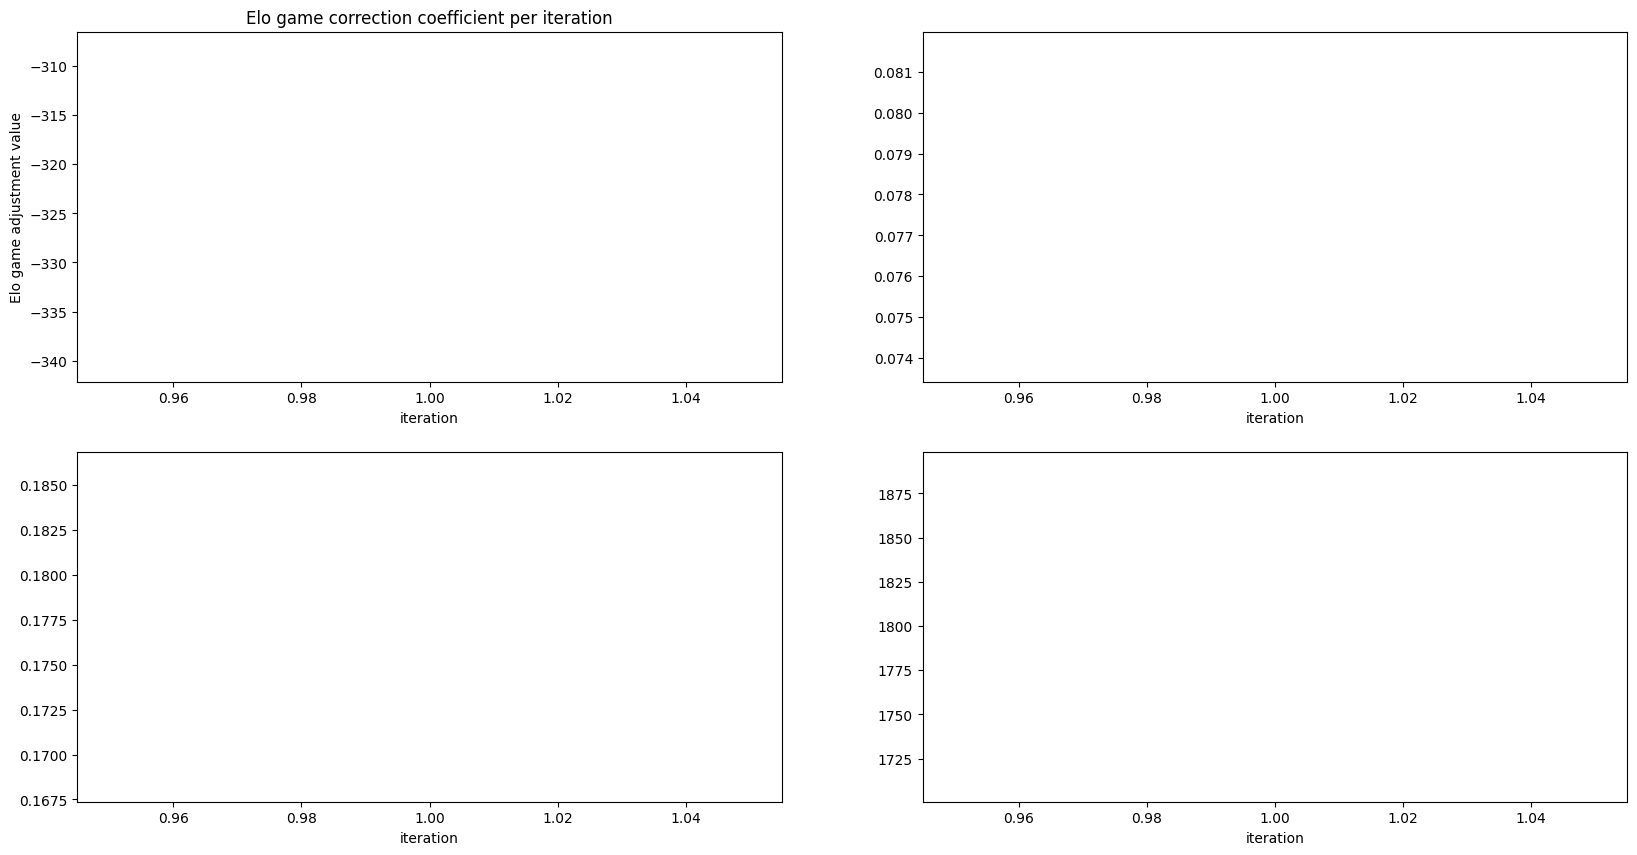

In [18]:
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(20, 10))
index = 0
axs = axs.flatten()
for col in ['elo_game_value', 'num_rounds_degree_value', 'num_drivers_degree_value', 'default_rating_value']:
    axs[index].plot(output_df['iteration'], output_df[col])
    axs[index].set_xlabel('iteration')
    axs[index].set_ylabel(col_name_mapping.get(col))
    axs[index].set_title(titles.get(col))
    index += 1
# plt.tight_layout(pad=0.5, w_pad=0.5, h_pad=5.0)

In [19]:
titles = {
    0: 'Log loss value per iteration for a validation dataset',
    40: 'Detailed view of log loss value for a validation dataset starting from iteration 40',
}

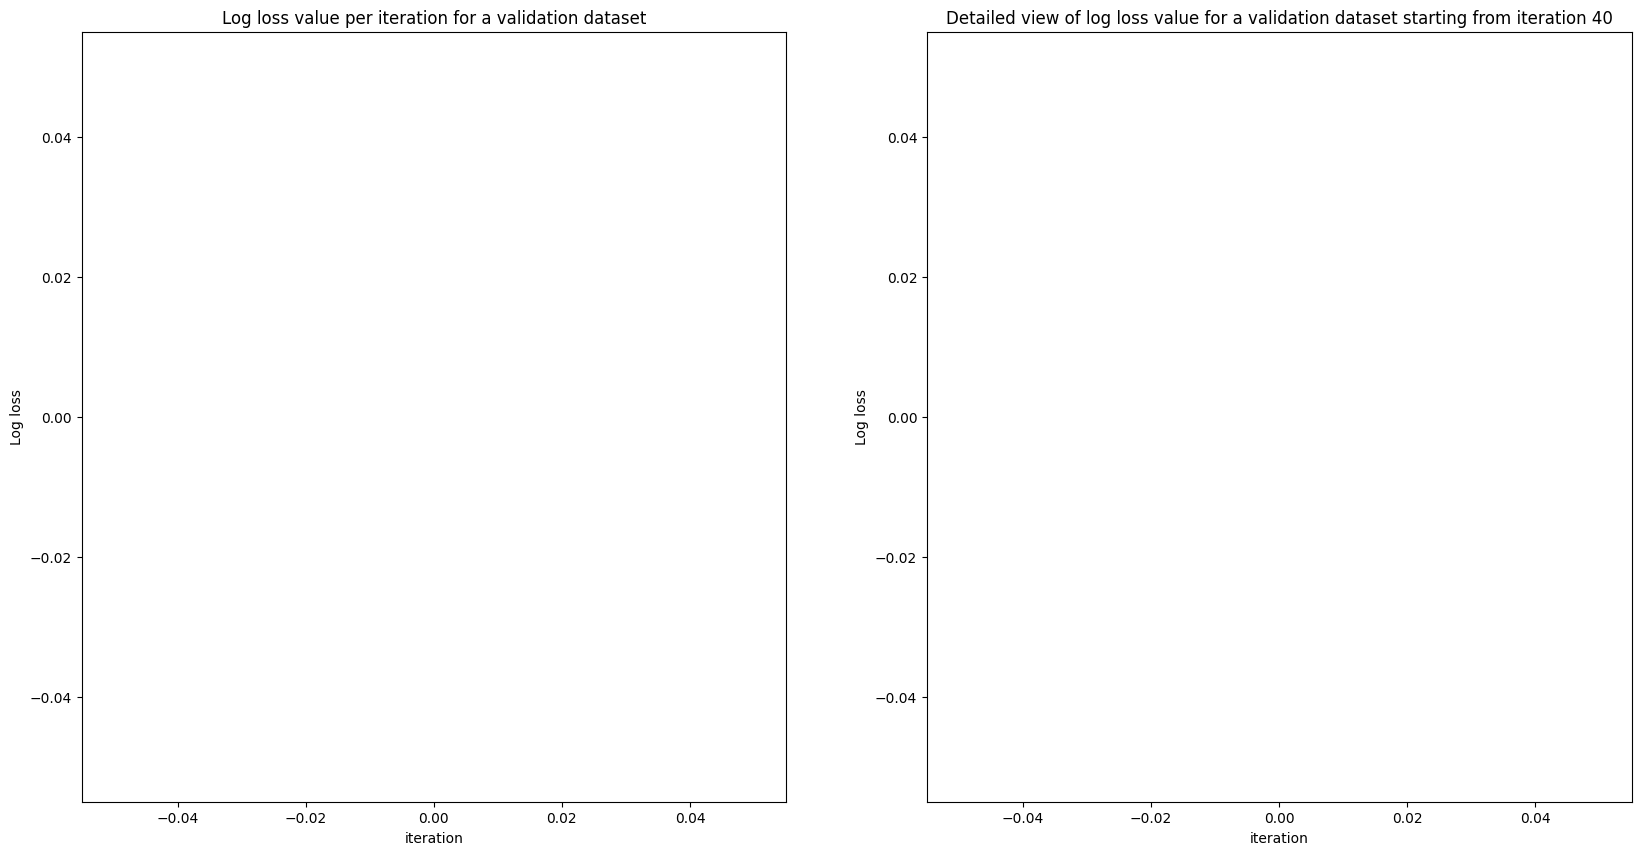

In [20]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(20, 10))
index = 0
axs = axs.flatten()
for start_iter in [0, 40]:
    ix = output_df['iteration'] > start_iter
    axs[index].plot(output_df['iteration'].loc[ix], output_df['new_validation_log_loss'].loc[ix])
    axs[index].set_xlabel('iteration')
    axs[index].set_ylabel('Log loss')
    axs[index].set_title(titles.get(start_iter))
    index += 1
# plt.tight_layout(pad=0.5, w_pad=0.5, h_pad=5.0)